In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons,make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:

X, y=make_moons(n_samples=500, noise=0.05, random_state=42)
df = pd.DataFrame(data=X, columns=["Feature1","Feature2"])
df["Clusters"]=y
print("First 10 rows of the Synthetic Dataset : \n")
print(df)
print("The shape of the dataset : ",df.shape)


First 10 rows of the Synthetic Dataset : 

     Feature1  Feature2  Clusters
0    0.830586 -0.447733         1
1    0.701678  0.816918         0
2    1.022080 -0.492571         1
3   -0.316765  0.953438         0
4    0.293226  1.057185         0
..        ...       ...       ...
495  0.239754  0.985462         0
496  0.072145  0.184834         1
497  0.590273 -0.365577         1
498  1.619465 -0.283658         1
499  0.228960  1.063974         0

[500 rows x 3 columns]
The shape of the dataset :  (500, 3)


In [4]:
scaler = StandardScaler()
X_scaled = df.copy()
X_scaled[["Feature1","Feature2"] ]= scaler.fit_transform(X_scaled[["Feature1","Feature2"]])
print("First five rows of scaled dataset : ")
print(X_scaled)

First five rows of scaled dataset : 
     Feature1  Feature2  Clusters
0    0.375125 -1.403679         1
1    0.226815  1.135628         0
2    0.595442 -1.493710         1
3   -0.944918  1.409748         0
4   -0.243115  1.618062         0
..        ...       ...       ...
495 -0.304636  1.474047         0
496 -0.497472 -0.133542         1
497  0.098642 -1.238718         1
498  1.282741 -1.074231         1
499 -0.317055  1.631692         0

[500 rows x 3 columns]


In [5]:
KMeans_model = KMeans(n_clusters=2,random_state=42,n_init=10)
X_scaled["KMeans_Clusters"] = KMeans_model.fit_predict(X_scaled[["Feature1","Feature2"]])
print("The first five rows of thedataset after KMeans Clustering : ")
print(X_scaled.head(5))

The first five rows of thedataset after KMeans Clustering : 
   Feature1  Feature2  Clusters  KMeans_Clusters
0  0.375125 -1.403679         1                0
1  0.226815  1.135628         0                1
2  0.595442 -1.493710         1                0
3 -0.944918  1.409748         0                1
4 -0.243115  1.618062         0                1


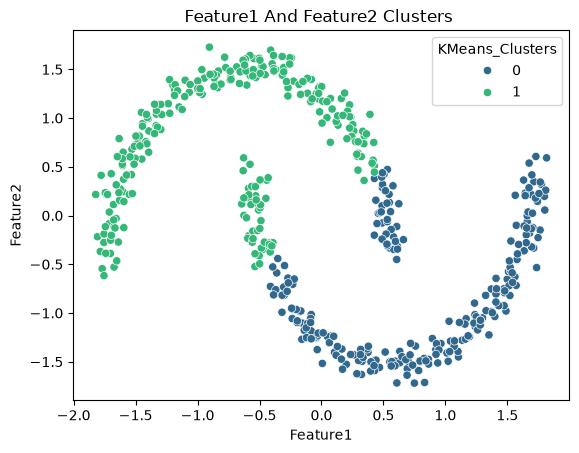

In [6]:
sns.scatterplot(data=X_scaled,x="Feature1", y="Feature2",hue="KMeans_Clusters",markers="o",palette="viridis")
plt.title("Feature1 And Feature2 Clusters ")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [7]:
DBSCAN_model =DBSCAN(eps=0.3, min_samples=5)
X_scaled["DBSCAN_Clusters"] = DBSCAN_model.fit_predict(X_scaled[["Feature1","Feature2"]])
print("The first five rows of the dataset after DBSCAN Clustering : ")
print(X_scaled.head(5)) 

The first five rows of the dataset after DBSCAN Clustering : 
   Feature1  Feature2  Clusters  KMeans_Clusters  DBSCAN_Clusters
0  0.375125 -1.403679         1                0                0
1  0.226815  1.135628         0                1                1
2  0.595442 -1.493710         1                0                0
3 -0.944918  1.409748         0                1                1
4 -0.243115  1.618062         0                1                1


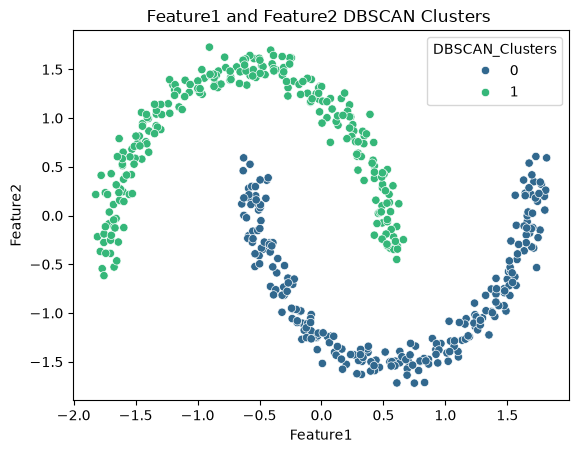

In [8]:
sns.scatterplot(data=X_scaled,x="Feature1", y="Feature2",hue="DBSCAN_Clusters", markers="o",palette="viridis")
plt.title("Feature1 and Feature2 DBSCAN Clusters ")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

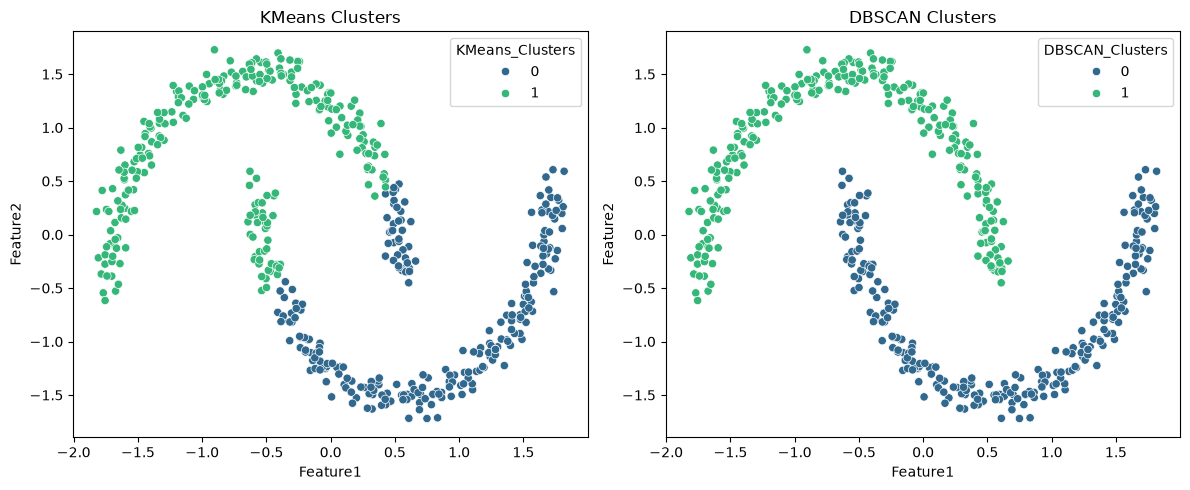

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=X_scaled, x="Feature1", y="Feature2", hue="KMeans_Clusters", palette="viridis", ax=axes[0])
axes[0].set_title("KMeans Clusters")
axes[0].set_xlabel("Feature1")
axes[0].set_ylabel("Feature2")
sns.scatterplot(data=X_scaled, x="Feature1", y="Feature2", hue="DBSCAN_Clusters", palette="viridis", ax=axes[1])
axes[1].set_title("DBSCAN Clusters")
axes[1].set_xlabel("Feature1")
axes[1].set_ylabel("Feature2")
plt.tight_layout()
plt.show()

In [10]:
eps_values = [0.2, 0.3, 0.4, 0.5]
results = []
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled[["Feature1","Feature2"]])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    results.append([eps, n_clusters, n_noise])
results_df = pd.DataFrame(results, columns=["eps", "Number of Clusters", "Number of Noise Points"])
print(results_df)

   eps  Number of Clusters  Number of Noise Points
0  0.2                   2                       0
1  0.3                   2                       0
2  0.4                   2                       0
3  0.5                   2                       0


In [11]:
X_high, y_high = make_blobs(n_samples=500, n_features=6, centers=4, cluster_std=1.5, random_state=42)
scaler_high = StandardScaler()
X_scaled_high = scaler_high.fit_transform(X_high)
print("Scaled High Dimensional Data : ")
print(X_scaled_high)

Scaled High Dimensional Data : 
[[-1.05251282  0.71908254  0.35044427  0.98965683 -1.61959701  1.41449866]
 [ 0.14079531 -1.04061999  0.84157371 -0.85710764  0.45873132 -0.55629338]
 [-0.14330172  1.11304882  0.7856684   0.68664305 -0.15354279 -1.52412444]
 ...
 [ 0.12079085 -0.78202579  0.52527576 -1.49949759  1.149061   -0.29441371]
 [-0.07572188  0.87357878  0.73479041  0.39837176 -0.36670079 -0.88491646]
 [-0.97217897  0.83710981  0.42247111  1.61220533 -1.23108893  2.11259434]]


In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_high)
pca_df = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
pca_df["Original_Cluster"] = y_high
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.64327878 0.21039738]


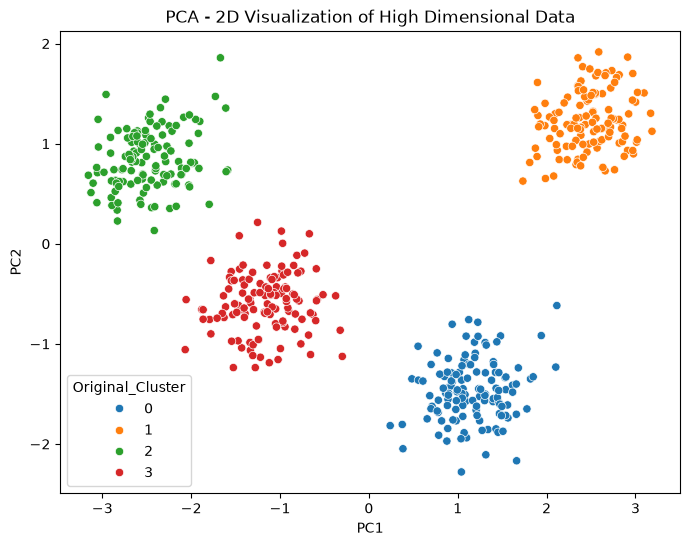

Explained Variance Ratio Sum: 0.8536761598958891


In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Original_Cluster", palette="tab10")
plt.title("PCA - 2D Visualization of High Dimensional Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
print("Explained Variance Ratio Sum:", sum(pca.explained_variance_ratio_))

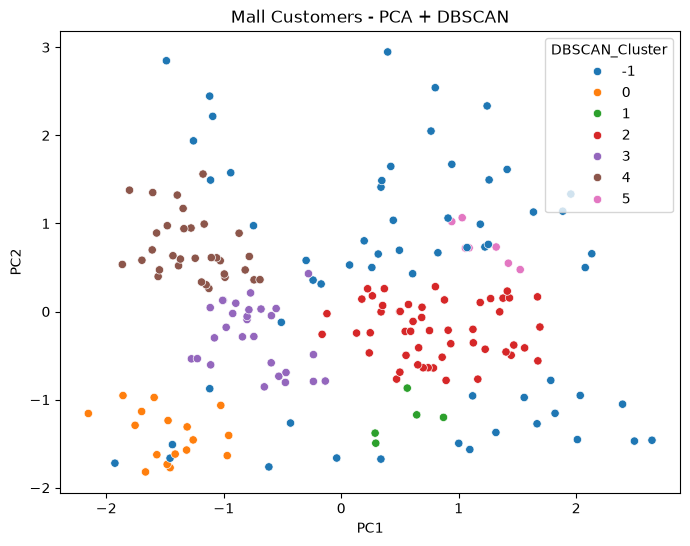

In [14]:
df_mall = pd.read_csv("Mall_Customers.csv")
df_num = df_mall[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler_mall = StandardScaler()
X_mall_scaled = scaler_mall.fit_transform(df_num)
dbscan_mall = DBSCAN(eps=0.5, min_samples=5)
mall_dbscan_labels = dbscan_mall.fit_predict(X_mall_scaled)
df_num["DBSCAN_Cluster"] = mall_dbscan_labels
pca_mall = PCA(n_components=2)
X_mall_pca = pca_mall.fit_transform(X_mall_scaled)
pca_mall_df = pd.DataFrame(X_mall_pca, columns=["PC1", "PC2"])
pca_mall_df["DBSCAN_Cluster"] = mall_dbscan_labels
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_mall_df, x="PC1", y="PC2", hue="DBSCAN_Cluster", palette="tab10")
plt.title("Mall Customers - PCA + DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()